In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import fpbase

In [2]:
def get_FRET_pair(donor_dye,acceptor_dye):
    """
        Gets excitation and emission spectra of acceptor and donor dyes respectively

        Args:
            donor_dye (str): name of the donor fluorophore on FPBASE
            acceptor_dye (str): name of the acceptor fluorophore on FPBASE

        Returns:
            donor (data frame): wavelengths and correspoinding fluorescence emission (in arbitrary units)
            acceptor (data frame): wavelenths and corresponding excitation (in extinction coefficient M^-1 cm^-1)
            QY_D (float): quantum yield of the donor
            QY_A (float): quantum yield of the acceptor
     """    
    donor_obj = fpbase.get_fluorophore(donor_dye).default_state
    list_sorted = [x for x in donor_obj.spectra if "EM" in x.subtype]
    if len(list_sorted) > 0:
            donor_rawdata = np.array(list_sorted[0].data)
            donor_rawwavelength = donor_rawdata[:, 0]
            donor_rawspectrum = donor_rawdata[:, 1]
            donor_rawspectrum[donor_rawspectrum < 0.0] = 0.0
    
    donor = pd.DataFrame(donor_rawwavelength,columns=['wavelength'])
    donor['Emission (AU)'] = pd.DataFrame(donor_rawspectrum,columns=['Emission (AU)'])
    QY_D = donor_obj.qy

    acceptor_obj = fpbase.get_fluorophore(acceptor_dye).default_state
    list_sorted = [x for x in acceptor_obj.spectra if "AB" in x.subtype]
    if len(list_sorted) > 0:
            acceptor_rawdata = np.array(list_sorted[0].data)
            acceptor_rawwavelength = acceptor_rawdata[:, 0]
            acceptor_rawspectrum = acceptor_rawdata[:, 1]
            acceptor_rawspectrum[acceptor_rawspectrum < 0.0] = 0.0
            acceptor_scaledspectrum = acceptor_rawspectrum*acceptor_obj.ext_coeff
    
    QY_A = acceptor_obj.qy
    acceptor = pd.DataFrame(acceptor_rawwavelength,columns=['wavelength'])
    acceptor['absorption'] = pd.DataFrame(acceptor_scaledspectrum,columns=['absorption'])

    return acceptor, donor, QY_D, QY_A


In [40]:
acceptor, donor, QY_D, QY_A = get_FRET_pair('Cy3','Cy5')
acceptor
donor
if QY_D == None:
    QY_D =0.01
print("Donor QY = ",QY_D)
print("Acceptor QY = ",QY_A)

Donor QY =  0.15
Acceptor QY =  0.3


In [41]:
if acceptor['wavelength'].iloc[0] > donor['wavelength'].iloc[0]: #find the longest wavelength they share early on
    integral_start = acceptor['wavelength'].iloc[0] 
else:
    integral_start = donor['wavelength'].iloc[0]

if acceptor['wavelength'].iloc[-1] > donor['wavelength'].iloc[-1]: #find the shortest wavelength at the end of the spectra
    integral_end = donor['wavelength'].iloc[-1]
else:
    integral_end = acceptor['wavelength'].iloc[-1]
donor = donor[donor['wavelength'] > integral_start] #now each spectra should have the same wavlengths
donor = donor[donor['wavelength'] < integral_end]
donor['Emission (norm)'] = donor['Emission (AU)']/np.trapz(donor['Emission (AU)'])

acceptor = acceptor[acceptor['wavelength'] > integral_start]
acceptor = acceptor[acceptor['wavelength'] < integral_end]

In [42]:
waverange = np.multiply(acceptor['wavelength'].to_numpy(),1E-9)
acceptor_abs = acceptor['absorption'].to_numpy()
donor_em = donor['Emission (norm)'].to_numpy()

overlap = np.multiply(acceptor_abs,donor_em)
J = np.trapz(np.multiply(overlap,waverange**4))

In [43]:
J

4.875359890502004e-21

Text(0.5, 0, 'wavelength/m')

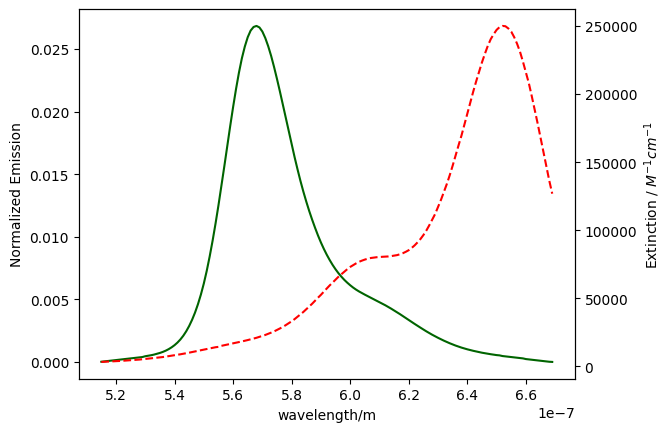

In [44]:
fig, ax1 = plt.subplots()
ax1.plot(waverange,donor_em,color='darkgreen')
ax2 = ax1.twinx()
ax2.plot(waverange,acceptor_abs,color='red',linestyle='--')
ax2.set_ylabel('Extinction / $M^{-1} cm^{-1}$')
ax1.set_ylabel('Normalized Emission')
ax1.set_xlabel('wavelength/m')

In [45]:
kappa_sqr = 2/3
n_fourth = 1.33**(-4)

R0 = (2.11E-5)*np.power(kappa_sqr*n_fourth*QY_D*J,(1/6))

R0_nm = np.multiply(R0,1E9)
print("forster radius = ", "{:.2f}".format(R0_nm),"nm" )

forster radius =  4.89 nm


3.8626262626262626 nm at 0.8 E
6.1202020202020195 nm at 0.2 E


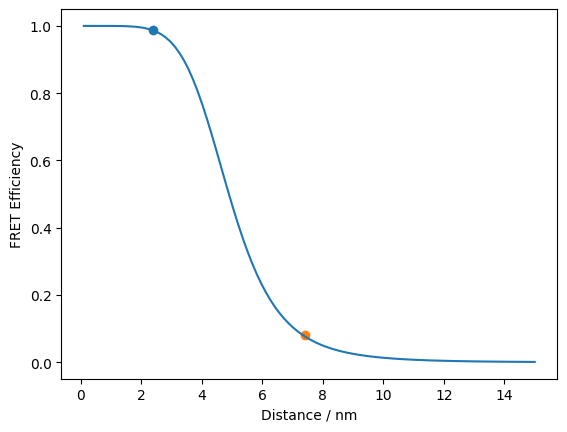

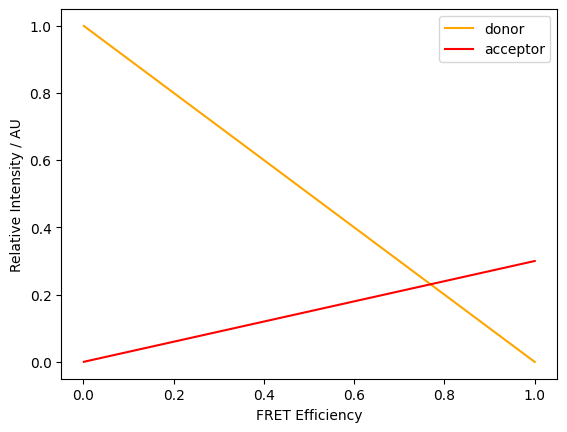

In [46]:
r = np.linspace(0.1,15,100)
E = np.divide(1,1 + np.power(np.divide(r,R0_nm),6))

fig,ax1 = plt.subplots(1)
ax1.plot(r,E)
ax1.set_xlabel('Distance / nm')
ax1.set_ylabel('FRET Efficiency')
ax1.scatter(R0_nm-2.5, E[np.argmin(np.abs(r-(R0_nm-2.5)))])
ax1.scatter(R0_nm+2.5, E[np.argmin(np.abs(r-(R0_nm+2.5)))])
print('{} nm at 0.8 E'.format(r[np.argmin(np.abs(E - 0.8))]))
print('{} nm at 0.2 E'.format(r[np.argmin(np.abs(E - 0.2))]))

donor_intens_0 = 1
donor_intens = np.multiply((1-E),donor_intens_0)
acceptor_intens = np.multiply((donor_intens_0 -donor_intens),QY_A)
fig,ax2 = plt.subplots(1)
ax2.plot(E,donor_intens,color='orange',label=f'donor')
ax2.plot(E,acceptor_intens,color='r',label=f'acceptor')
ax2.set_ylabel('Relative Intensity / AU')
ax2.set_xlabel('FRET Efficiency')
ax2.legend()


In [19]:
np.sqrt(4.25**2 + 5**2)

6.562202374203344

In [12]:
ATTO488_colours = [0.17,0.77,0.06]
ATTO647N_colours = [0.07,0.22,0.71]

E_range = np.linspace(0,1,101)
fret_response = np.zeros((101,3))
for i in range(E_range.size):
    donor_contribution = np.multiply(ATTO488_colours,(1-E_range[i]))
    acceptor_contribution = np.multiply(ATTO647N_colours,QY_A*(E_range[i]))
    fret_total = donor_contribution + acceptor_contribution
    fret_response[i,:] = fret_total/np.sum(fret_total)



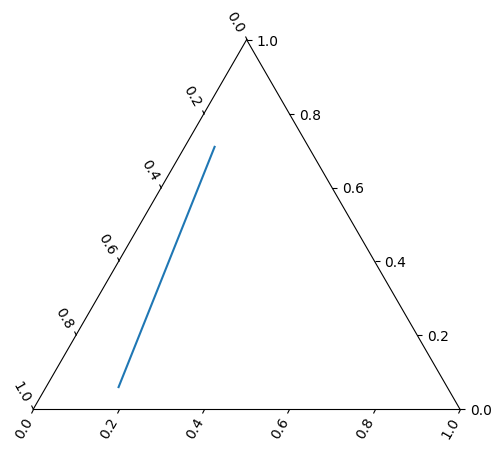

In [13]:
import mpltern
ax = plt.subplot(projection='ternary')
ax.plot(fret_response[:,2],fret_response[:,1],fret_response[:,0])
